In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def logistic_map(a,n= 1000,x_0 =0.1):
    x = np.ones(n)*x_0
    for i in range(n-1):
        x[i+1] = a*x[i]*(1-x[i])
    T = np.arange(n)
    return T, x

def bifuracation_diagram(a_list,n,x_0, x_map = logistic_map):
    points = np.zeros((len(a_list),round(n/100)))
    for i, a in enumerate(a_list):
        t, x = x_map(a,n,x_0)
        t, x2 = x_map(a,round(n/100),x[-1])
        points[i,:] = x2
    return points

def sin_map(a,n= 1000,x_0 =0.1):
    x = np.ones(n)*x_0
    for i in range(n-1):
        x[i+1] = a*np.sin(np.pi*x[i])
    T = np.arange(n)
    return T, x



In [31]:
t, x = logistic_map(2.8,10000,0.01)
t, x2 = logistic_map(3.3,10000,0.01)

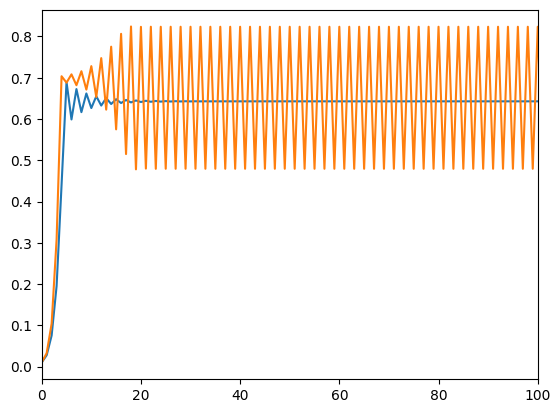

In [32]:
plt.plot(t,x)
plt.plot(t,x2)
plt.xlim(0,100)
plt.show()

In [50]:
aL = np.linspace(0,4,100)
x = bifuracation_diagram(aL,10000, 0.1 )

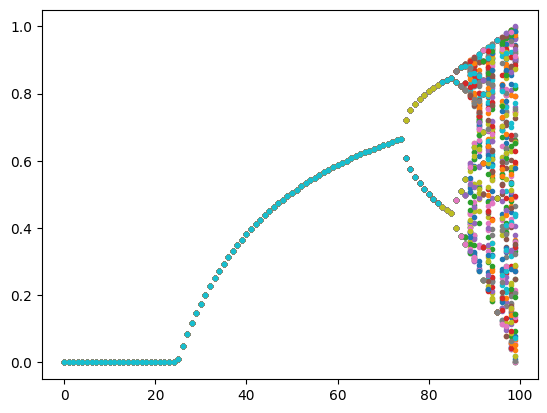

In [52]:
plt.plot(x, '.')
plt.show()

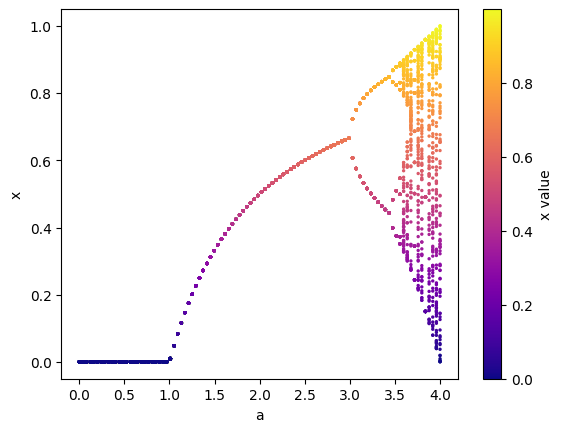

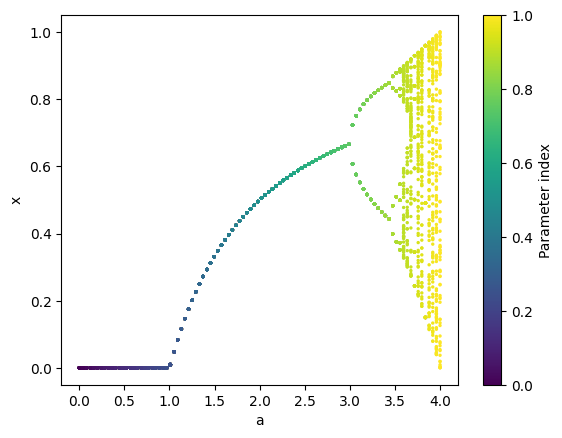

In [56]:
plt.scatter(np.repeat(aL, x.shape[1]), x.flatten(), s=2, c=x.flatten(), cmap='plasma')
plt.xlabel("a")
plt.ylabel("x")
plt.colorbar(label="x value")
plt.show()

colors = np.repeat(np.linspace(0, 1, len(aL)), x.shape[1])
plt.scatter(np.repeat(aL, x.shape[1]), x.flatten(), s=2, c=colors, cmap='viridis')
plt.xlabel("a")
plt.ylabel("x")
plt.colorbar(label="Parameter index")
plt.show()


In [68]:
aL2 = np.linspace(0,1,100)
x2 = bifuracation_diagram(aL2,10000, 0.1, sin_map)#

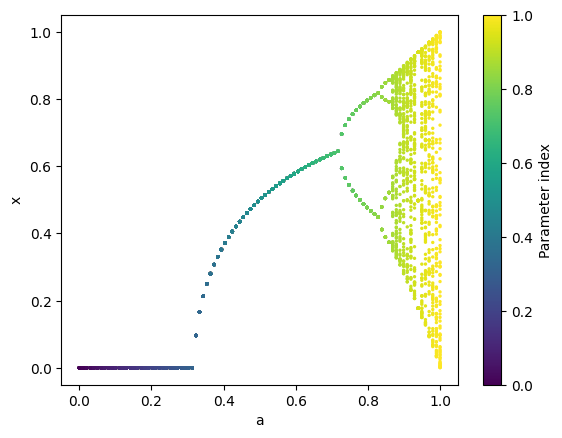

In [69]:
colors = np.repeat(np.linspace(0, 1, len(aL)), x2.shape[1])
plt.scatter(np.repeat(aL2, x2.shape[1]), x2.flatten(), s=2, c=colors, cmap='viridis')
plt.xlabel("a")
plt.ylabel("x")
plt.colorbar(label="Parameter index")
plt.show()

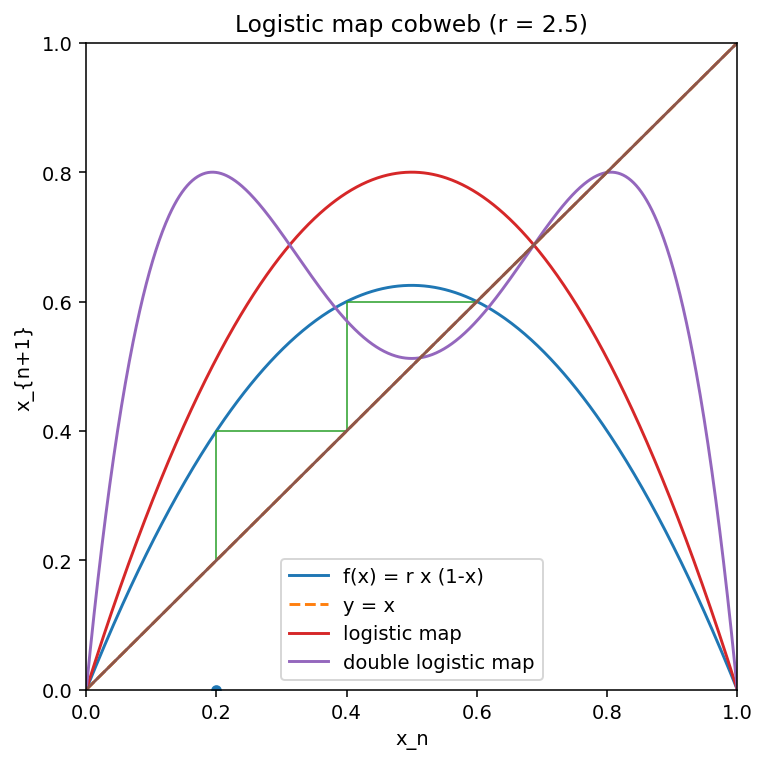

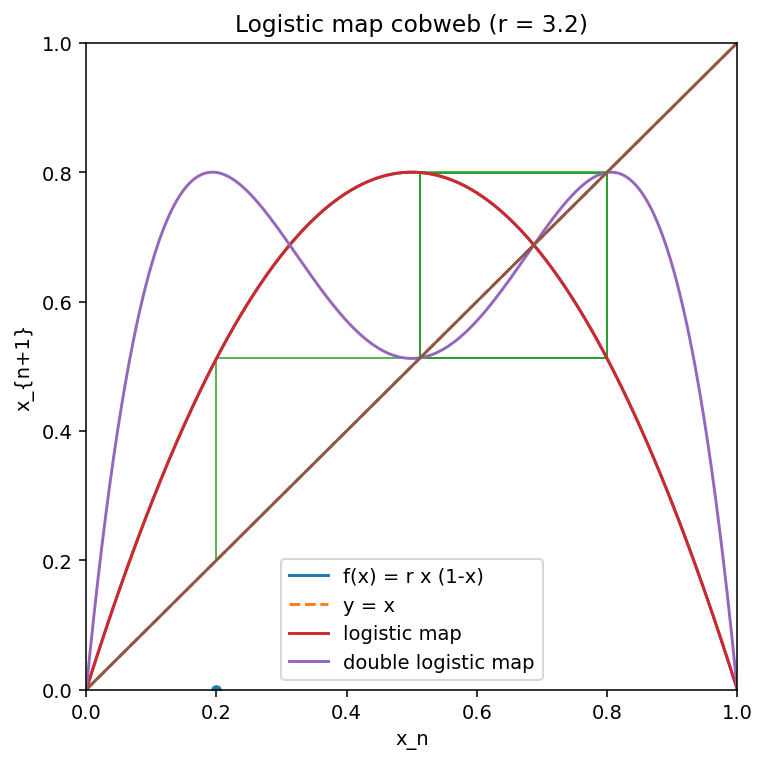

In [82]:
# Cobweb plots for the logistic map to illustrate (1) a single stable fixed point and (2) a stable period-2 cycle.
import numpy as np
import matplotlib.pyplot as plt

def logistic(x, r):
    return r * x * (1 - x)

def cobweb_plot(r, x0=0.2, n_iter=50, n_show=30):
    # domain
    xs = np.linspace(0, 1, 500)
    fxs = logistic(xs, r)

    # iterate
    x = x0
    traj = [x]
    for _ in range(n_iter):
        x = logistic(x, r)
        traj.append(x)

    # Build cobweb segments
    seg_x = []
    seg_y = []
    x = x0
    for k in range(n_show):
        y = logistic(x, r)
        # vertical segment (x, f(x))
        seg_x.extend([x, x])
        seg_y.extend([x, y])
        # horizontal to (f(x), f(x))
        seg_x.extend([x, y])
        seg_y.extend([y, y])
        x = y

    # Plot f(x) and the diagonal
    plt.figure(figsize=(6,6), dpi=140)
    plt.plot(xs, fxs, label="f(x) = r x (1-x)")
    plt.plot(xs, xs, linestyle="--", label="y = x")

    # Plot cobweb
    plt.plot(seg_x, seg_y, linewidth=0.8)
    plt.scatter([x0], [0], s=20)  # starting point on x-axis

    x0 = np.linspace(0,1,1000)

    y = [logistic_func(3.2,xi) for xi in x0]
    y2 = [logistic_func(3.2,yi) for yi in y]

    plt.plot(x0,y, label = "logistic map")
    plt.plot(x0,y2, label = "double logistic map")
    plt.plot(x0,x0)

    # cosmetics
    plt.title(f"Logistic map cobweb (r = {r})")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("x_n")
    plt.ylabel("x_{n+1}")
    plt.legend()
    plt.show()

# 1) Single stable fixed point: r=2.5
cobweb_plot(r=2.5, x0=0.2, n_iter=80, n_show=40)

# 2) Stable period-2 cycle: r=3.2
cobweb_plot(r=3.2, x0=0.2, n_iter=120, n_show=60)


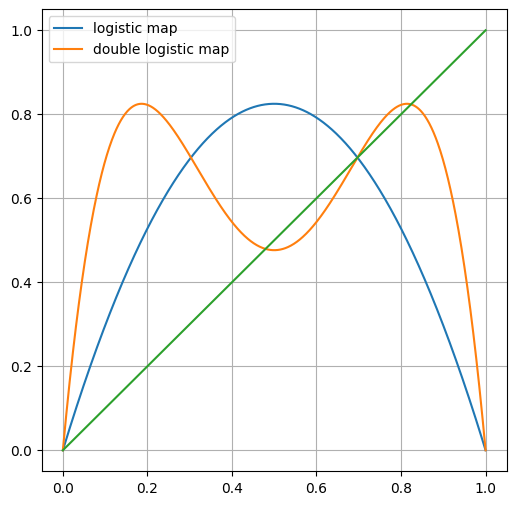

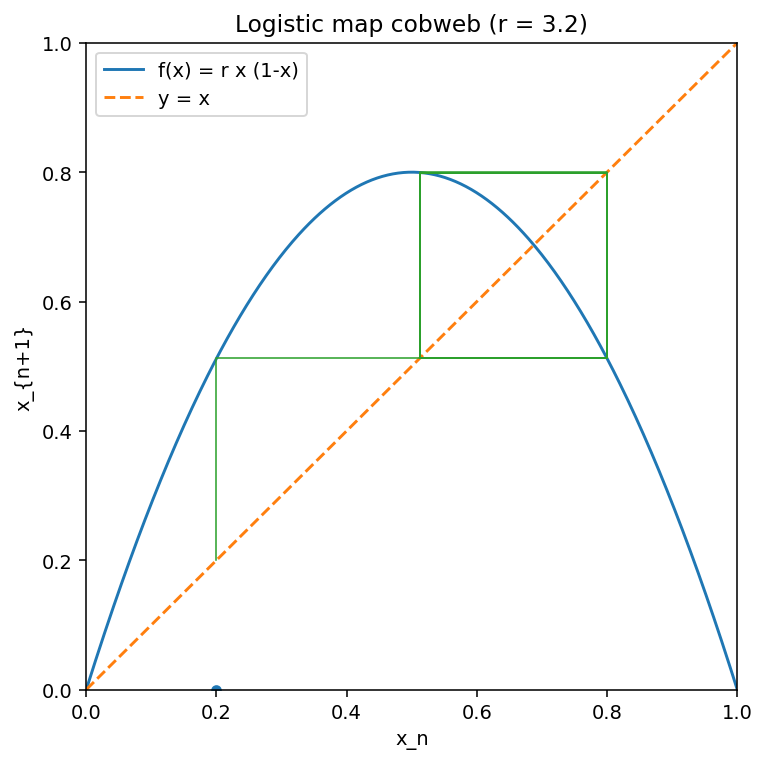

In [79]:
def logistic_func(a,x):
    x2 = a*x*(1-x)
    return x2
def lin_func(a,x):
    return a*x
x0 = np.linspace(0,1,1000)

y = [logistic_func(3.3,xi) for xi in x0]
y2 = [logistic_func(3.3,yi) for yi in y]

plt.figure(figsize=(6,6))
plt.plot(x0,y, label = "logistic map")
plt.plot(x0,y2, label = "double logistic map")
plt.plot(x0,x0)
plt.legend()
plt.grid()

# 2) Stable period-2 cycle: r=3.2
cobweb_plot(r=3.2, x0=0.2, n_iter=120, n_show=60)

plt.show()

# Excercise 3 

In [77]:
# coupled_map_lattice.py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from matplotlib import cm, colors

# ---------- Core map ----------
def logistic(x, a):
    # f(x) = a x (1 - x)
    return a * x * (1.0 - x)

# ---------- 1D CML ----------
def simulate_1d(N=200, T=400, a=3.7, eps=0.2, seed=0):
    """
    1D coupled map lattice with diffusive coupling to nearest neighbors.
    Periodic boundary conditions.

    x_i(t+1) = (1-eps) f(x_i) + (eps/2)[ f(x_{i-1}) + f(x_{i+1}) ]
    """
    rng = np.random.RandomState(seed)
    x = rng.rand(N)  # initial condition in (0,1)
    hist = np.zeros((T, N))

    for t in range(T):
        hist[t] = x
        # compute f(x) first (we couple the mapped values)
        fx = logistic(x, a)

        # neighbors with periodic wrap
        fx_left = np.roll(fx, 1)
        fx_right = np.roll(fx, -1)

        # update
        x = (1.0 - eps) * fx + 0.5 * eps * (fx_left + fx_right)

    return hist  # shape (T, N)

def plot_spacetime_1d(hist, plot_every=1, title="1D CML space-time"):
    """
    Simple space-time diagram: time downward, space along x-axis.
    Set plot_every=2 or 16 to only plot every k-th time step (faster).
    """
    data = hist[::plot_every]
    plt.figure(figsize=(8, 4))
    plt.imshow(data, aspect='auto', origin='lower', interpolation='nearest', cmap="nipy_spectral")
    plt.xlabel("Lattice index i")
    plt.ylabel(f"Time (every {plot_every} step)")
    plt.title(title)
    plt.colorbar(label="x")
    plt.tight_layout()
    plt.show()

# ---------- 2D CML ----------
def simulate_2d(L=64, T=200, a=3.7, eps=0.2, seed=0):
    """
    2D coupled map lattice on an LxL grid with von Neumann neighbors (up, down, left, right).
    Periodic boundary conditions.

    x_{i,j}(t+1) = (1-eps) f(x_{i,j}) + (eps/4) * sum_{n in N(i,j)} f(x_n)
    """
    rng = np.random.RandomState(seed)
    x = rng.random((L,L))
    hist = np.zeros((T,L,L))

    for t in range(T):
        hist[t] = x

        fx = logistic(x, a)

        fx_up = np.roll(fx, 1, axis = 1)
        fx_down = np.roll(fx, -1, axis = 1)
        fx_left = np.roll(fx, 1, axis = 0)
        fx_right = np.roll(fx, -1, axis = 0)

        x = fx * (1-eps) + (eps/4) * (fx_up + fx_down + fx_left + fx_right)
    return hist

def plot_snapshots_2d(hist, every=16, max_plots=6, title="2D CML snapshots"):
    """
    Plot up to max_plots snapshots, taken every 'every' steps (e.g., 2 or 16).
    """
    T = hist.shape[0]
    times = list(range(0, T, every))[:max_plots]
    n = len(times)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4*cols, 4*rows))
    for k, t in enumerate(times, start=1):
        plt.subplot(rows, cols, k)
        plt.imshow(hist[t], origin='lower', interpolation='nearest', cmap = "plasma")
        plt.title(f"t = {t}")
        plt.axis('off')
    
    plt.suptitle(title)
    
    plt.tight_layout()
    plt.show()

def plot_snapshots_3d(hist, step_size=16, title="2D CML snapshots (3D time stack)",
                      elev=30, azim=-60, cmap_name="plasma"):
    """
    3D stack of 2D snapshots from time 0 to last time, every `step_size` steps.
    Each snapshot is a colored surface positioned at z = t; color encodes x.

    Parameters
    ----------
    hist : ndarray, shape (T, L, L)
        Time series of 2D states.
    step_size : int
        Plot every `step_size` time steps (e.g., 2 or 16).
    elev, azim : floats
        Initial viewing angles for the 3D axes.
    cmap_name : str
        Matplotlib colormap name.
    """
    T, L, _ = hist.shape
    times = range(0, T, step_size)

    # grid for a single LxL surface
    j = np.arange(L)
    i = np.arange(L)
    J, I = np.meshgrid(j, i)  # X=cols (j), Y=rows (i)

    # color normalization across all times so colors are comparable
    vmin = np.min(hist)
    vmax = np.max(hist)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmap_name)

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d')

    for t in times:
        Z = np.full((L, L), t, dtype=float)        # place this layer at height z=t
        facecolors = cmap(norm(hist[t]))           # map values to colors
        # draw surface (flat sheet at z=t, colored by values)
        ax.plot_surface(J, I, Z, rstride=1, cstride=1,
                        facecolors=facecolors, shade=False, linewidth=0, alpha = 0.7)

    # nice view + labels
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("j (x-index)")
    ax.set_ylabel("i (y-index)")
    ax.set_zlabel("time t")
    ax.set_title(title)

    # add a colorbar using a scalar mappable
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])  # required by Matplotlib
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.7, pad=0.1)
    cbar.set_label("x value")

    plt.tight_layout()
    plt.show()




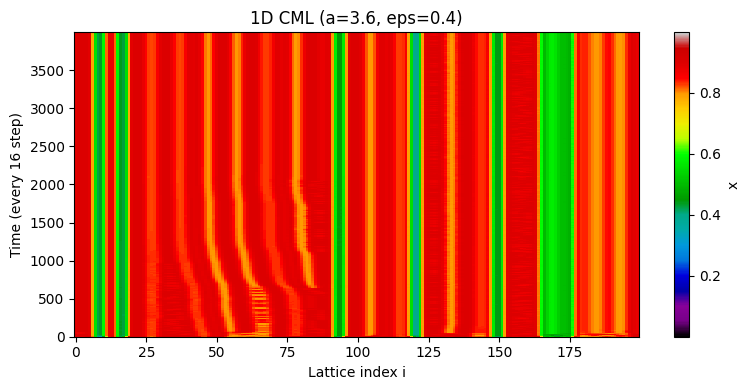

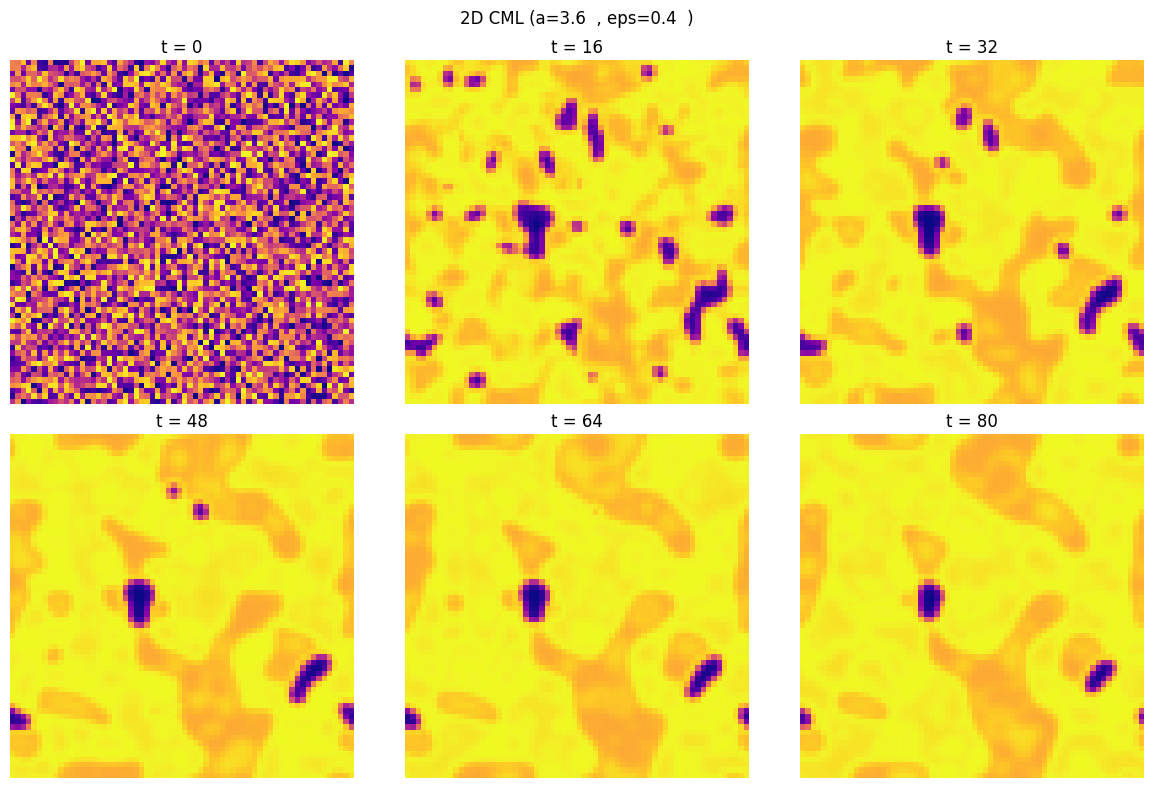

In [81]:
A  = 3.6
EPS = 0.4
# 1D example
#hist1d = simulate_1d(N=200, T=64000, a=A, eps=EPS, seed=1)
plot_spacetime_1d(hist1d, plot_every=16, title=f"1D CML (a={A}, eps={EPS})")

# 2D example
#hist2d = simulate_2d(L=64, T=800, a=A, eps=EPS, seed=1)
plot_snapshots_2d(hist2d, every=16, max_plots=6, title=f"2D CML (a={A}  , eps={EPS}  )")


C:\Users\lucq0\AppData\Local\Temp\ipykernel_1284\1798720381.py:130: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


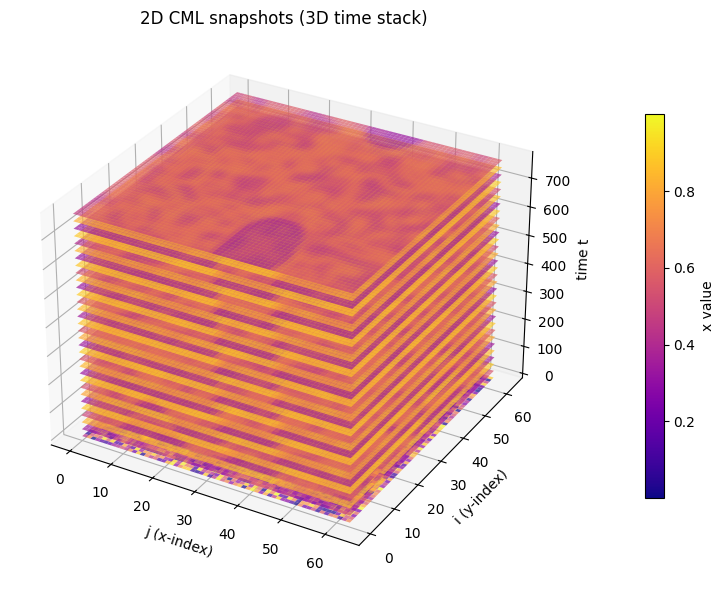

In [78]:
plot_snapshots_3d(hist2d, step_size=25)

In [ ]:
# ---------- Simple parameter scans (pattern changes) ----------
def demo_scan_1d(a_list=(3.5, 3.7, 3.9), eps_list=(0.05, 0.2, 0.4),
                 N=200, T=400, plot_every=2, seed=0):
    """
    Make a grid of space-time plots for different (a, eps) to see pattern changes.
    """
    rows = len(a_list)
    cols = len(eps_list)
    plt.figure(figsize=(4*cols, 3*rows))
    plot_idx = 1
    for a in a_list:
        for eps in eps_list:
            hist = simulate_1d(N=N, T=T, a=a, eps=eps, seed=seed)
            data = hist[::plot_every]
            plt.subplot(rows, cols, plot_idx)
            plt.imshow(data, aspect='auto', origin='lower', interpolation='nearest')
            plt.title(f"a={a}, eps={eps}")
            plt.xticks([]); plt.yticks([])
            plot_idx += 1
    plt.suptitle(f"1D CML space-time (every {plot_every} steps)")
    plt.tight_layout()
    plt.show()

def demo_scan_2d(a_list=(3.5, 3.7, 3.9), eps_list=(0.05, 0.2, 0.4),
                 L=48, T=160, every=16, seed=0):
    """
    For each (a, eps), show one snapshot taken at t ~ T-1 (or nearest multiple of 'every').
    """
    rows = len(a_list)
    cols = len(eps_list)
    plt.figure(figsize=(4*cols, 4*rows))
    plot_idx = 1
    for a in a_list:
        for eps in eps_list:
            hist = simulate_2d(L=L, T=T, a=a, eps=eps, seed=seed)
            # choose a late snapshot on a multiple of 'every' if possible
            t = T - 1 - ((T - 1) % every)
            plt.subplot(rows, cols, plot_idx)
            plt.imshow(hist[t], origin='lower', interpolation='nearest')
            plt.title(f"a={a}, eps={eps}, t={t}")
            plt.axis('off')
            plot_idx += 1
    plt.suptitle(f"2D CML snapshots (every {every} steps suggested)")
    plt.tight_layout()
    plt.show()
